# Encontro 1 - Insper AI - Introdução ao Machine Learning e Regressão Linear

---
*Autor: Thomas Kassabian - Diretor da Insper AI*  
*Colaboradores: --*   
*Atualizado em: 09/2025*  

---

## Workflow Completo de Machine Learning

Neste notebook, será implementado um **workflow completo de machine learning** aplicado a um problema de regressão. Utilizaremos o dataset de preços de casas da Califórnia para demonstrar todas as etapas do processo.

### Objetivo:
Desenvolver um modelo para prever preços de casas na Califórnia seguindo as etapas do workflow de ML.

### Etapas do Workflow:
1. **Análise Exploratória de Dados (EDA)**
2. **Preparação dos Dados**
3. **Seleção e Treinamento do Modelo***
4. **Predições**
5. **Avaliação do Modelo**
6. **Conclusões e Próximos Passos**  

**Como o foco aqui é o workflow de machine learning e a regressão linear, você não precisa se preocupar em selecionar o melhor modelo. O objetivo é entender as etapas do processo.*

---

## Começando: importando bibliotecas e carregando dados

Nessa atividade, usaremos as seguintes bibliotecas:
- **pandas**: Biblioteca para manipulação e análise de dados estruturados.
- **numpy**: Biblioteca para operações matemáticas e manipulação de arrays.
- **sklearn**: Biblioteca com ferramentas para Machine Learning, incluindo datasets, modelos e métricas.
- **matplotlib**: Biblioteca para criação de visualizações gráficas.

In [1]:
# Importar bibliotecas essenciais
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Carregar o dataset da Califórnia e convertê-lo para um DataFrame do pandas
housing = fetch_california_housing(as_frame=True)
df = housing.frame

### Descrição do Dataset

O dataset utilizado neste projeto é o **California Housing Dataset**, que contém informações sobre características de diferentes regiões da Califórnia e o valor médio das casas em cada região. Este dataset é amplamente utilizado didaticamente em problemas de regressão.

#### Colunas do Dataset
1. **MedInc**: Renda média dos moradores da região (em dezenas de milhares de dólares).
2. **HouseAge**: Idade média das casas na região.
3. **AveRooms**: Média de quartos por residência.
4. **AveBedrms**: Média de quartos por dormitório.
5. **Population**: População total da região.
6. **AveOccup**: Média de ocupantes por residência.
7. **Latitude**: Latitude da região.
8. **Longitude**: Longitude da região.
9. **MedHouseVal**: Valor médio das casas na região (em centenas de milhares de dólares) - **variável target**.

#### Objetivo
O objetivo é prever o valor médio das casas (**MedHouseVal**) com base nas outras características fornecidas no dataset.

---

### 1. Análise Exploratória de Dados (EDA)

A **Exploração de Dados** é o primeiro passo crucial em qualquer projeto de machine learning. Nesta etapa, procura-se:

- **Entender a estrutura dos dados**: dimensões, tipos de variáveis, valores faltantes
- **Analisar a distribuição das variáveis**: histogramas, estatísticas descritivas
- **Identificar relações entre variáveis**: correlações, scatter plots
- **Detectar outliers e anomalias**: box plots, análise de valores extremos

**Tarefa 1.1:** Explore a estrutura básica dos dados.

**Instruções:**
1. Use `df.head()` para ver as primeiras linhas
2. Use `df.info()` para informações sobre tipos de dados e valores nulos
3. Use `df.describe()` para estatísticas descritivas

**Responda:**
- Quantas linhas e colunas tem o dataset?
- Há valores faltantes?


In [ ]:
# SEU CÓDIGO AQUI
# Explore as primeiras linhas do DataFrame

In [ ]:
# SEU CÓDIGO AQUI
# Informações sobre o DataFrame

In [ ]:
# SEU CÓDIGO AQUI
# Estatísticas descritivas

#### Visualização dos dados

**Tarefa 1.2:** Crie visualizações para entender melhor os dados.

**Instruções:**
1. Importe `matplotlib.pyplot` como `plt`
2. Crie uma figura com 3 subplots lado a lado (`figsize=(15, 5)`):
   - **Subplot 1**: Histograma da variável target `MedHouseVal`  
      - Objetivo: Visualizar a distribuição dos valores médios das casas e identificar padrões ou assimetrias.

   - **Subplot 2**: Histograma da feature `HouseAge` (idade das casas)  
      - Objetivo: Entender a distribuição das idades das casas no dataset.

   - **Subplot 3**: Box plot da variável target `MedHouseVal`  
      - Objetivo: Identificar outliers e entender a dispersão dos valores médios das casas.

**Dicas:**
- Use `plt.subplot(1, 3, n)` para criar subplots
- Para os histogramas: `plt.hist(df['coluna'], bins=30, alpha=0.7)`
- Para o boxplot: `plt.boxplot(df['MedHouseVal'])`
- Adicione títulos e labels nos eixos
- Use `plt.tight_layout()` para melhor organização

**Reflita:**
- Por que escolhemos essas visualizações?
- O que elas revelam sobre os dados?
- Que outras visualizações poderiam ser úteis?

In [13]:
# SEU CÓDIGO AQUI
# Importe a biblioteca e crie os 3 gráficos conforme instruções

**Tarefa 1.3:** Análise de correlação.

**Instruções:**
1. Calcule a correlação de cada feature com o target:
   - Use `df.corr()['MedHouseVal']` para obter correlações com o target
   - Remova a correlação do target consigo mesmo
   - Ordene por valor absoluto (decrescente)

2. Interprete os resultados:
   - Classifique cada correlação como forte (>0.5), moderada (0.3-0.5) ou fraca (<0.3)
   - Explique se a correlação é positiva ou negativa

3. **(EXTRA)** Crie um gráfico de barras horizontais mostrando as correlações:
   - Use cores diferentes para correlações positivas (verde) e negativas (vermelho)
   - Adicione os valores numéricos nas barras
   - Inclua uma linha vertical em x=0

**Reflita**:
- O que significa uma correlação positiva ou negativa no contexto do problema?
- Quais features parecem mais relevantes para prever o valor das casas?

In [19]:
### SEU CÓDIGO AQUI
# Obtenha e exiba as correlações entre as features e a target

### 2. Preparação dos Dados (Data Preprocessing)

Nesta etapa, preparamos os dados para o treinamento do modelo. Isso inclui:
- Separação das features (X) e target (y)
- Divisão em conjuntos de treino e teste
- Tratamento de valores faltantes (se houver)
- Normalização/padronização (se necessário)

**Tarefa 2.1:** Separe as features (X) e o target (y).

**Instruções:**
1. Crie `X` removendo a coluna target do DataFrame: `df.drop('MedHouseVal', axis=1)`
2. Crie `y` selecionando apenas a coluna target: `df['MedHouseVal']`
3. Exiba as dimensões de X e y

In [ ]:
# SEU CÓDIGO AQUI
# Separe features (X) e target (y)

**Tarefa 2.2:** Divida os dados em conjuntos de treino e teste.

**Instruções:**
1. Use `train_test_split` do scikit-learn para dividir os dados:
   - 80% para treino, 20% para teste
   - Use `random_state=42` para reprodutibilidade
2. As variáveis resultantes devem ser: `X_train`, `X_test`, `y_train`, `y_test`
3. Exiba o tamanho de cada conjunto

**Reflita:** 
- Por que é importante ter conjuntos separados de treino e teste?

In [ ]:
# SEU CÓDIGO AQUI
# Divida os dados em treino e teste

### 3. Seleção e Treinamento do Modelo

Agora vamos criar e treinar nosso modelo de regressão linear. A regressão linear é um algoritmo simples e interpretável que assume uma relação linear entre as features e o target.


### A Teoria da Regressão Linear

O objetivo da Regressão Linear é modelar a relação entre um conjunto de variáveis de entrada (features) e uma variável de saída **contínua** (o alvo). A premissa fundamental é que essa relação pode ser descrita por uma linha reta (no caso de uma feature) ou por um hiperplano (no caso de múltiplas features). Em resumo, é uma função de 1º grau que tenta satisfazer os dados fornecidos.

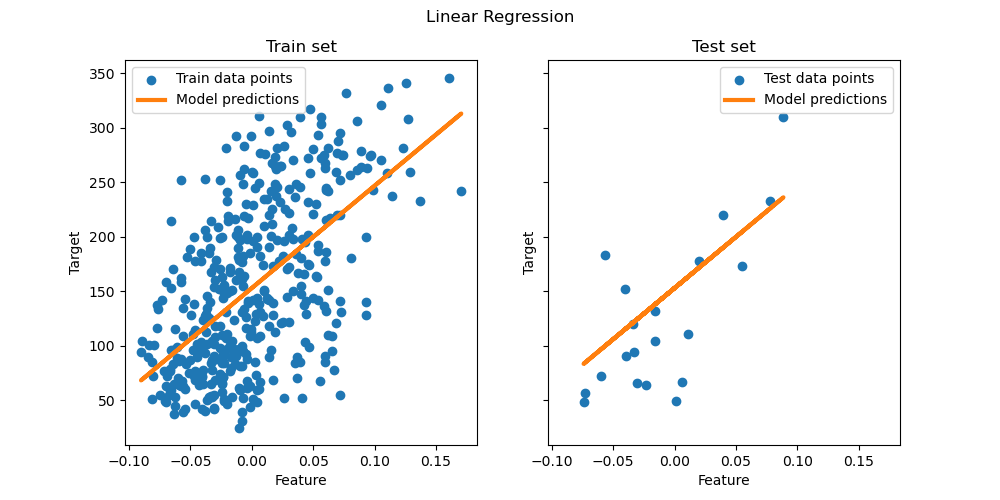  

#### O Caso Simples: Uma Única Variável

Começando com o caso mais simples, a equação de reta:

$$y = wx + b$$

Onde:
* $y$: o valor a ser previsto (o alvo).
* $x$: a única feature de entrada.
* $w$: o **coeficiente** ou **peso** (*weight*), que representa a inclinação da linha. Diz o quanto $y$ muda para cada unidade de mudança em $x$.
* $b$: o **intercepto** ou **bias**, que é o valor de $y$ quando $x$ é zero.

O "aprendizado" neste caso significa encontrar os melhores valores de $m$ e $b$ que fazem a linha passar o mais perto possível dos nossos pontos de dados.

#### Generalizando para Múltiplas Features

Na prática, raramente tem-se apenas uma feature. A equação é uma extensão direta do caso simples.

$$\hat{y} = b + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

#### Extra: A Forma Vetorizada (Usada na prática)

Para simplificar a notação e otimizar os cálculos computacionais, usa-se a forma vetorizada. Nela, os pesos são agrupados em um vetor $\mathbf{w}$ e todas as features em um vetor $\mathbf{x}$.

$$
\mathbf{w} = \begin{pmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \end{pmatrix}
\quad
\mathbf{x} = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{pmatrix}
$$

A equação se torna muito mais limpa:

$$\hat{y} = \mathbf{w}^T \cdot \mathbf{x} + b$$

Onde:
* $\mathbf{w}^T$: é o **transposto** do vetor de pesos (uma linha de pesos).
* $\cdot$: representa o **produto escalar** (*dot product*) entre os vetores.

É assim que bibliotecas como o scikit-learn implementam a regressão linear, utilizando operações vetorizadas para eficiência.

---

#### A Função de Custo

A **função de custo** é uma métrica que avalia o quão bem o modelo está ajustando os dados. No caso da regressão linear, a função de custo mais comum é o **Erro Quadrático Médio (MSE - Mean Squared Error)**. Ela mede a média dos quadrados das diferenças entre os valores reais ($y$) e os valores preditos ($\hat{y}$) pelo modelo, então, quanto menor o MSE, melhor a performance do modelo.

A fórmula do MSE é:

$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Onde:
- $n$: número de exemplos no conjunto de dados.
- $y_i$: valor real do exemplo $i$.
- $\hat{y}_i$: valor predito pelo modelo para o exemplo $i$ (equação da regressão linear).

Leve em conta que a função de custo depende dos parâmetros do modelo ($w$ e $b$), pois $\hat{y}_i$ é calculado usando esses parâmetros. Por isso, treinar o modelo é encontrar os valores ótimos de $w$ e $b$ que minimizam a função de custo (é assim que de fato o modelo "aprende"). Isso é feito através de algoritmos de otimização, como o **Gradiente Descendente**.

Nesse notebook, não entraremos em detalhes sobre o funcionamento do Gradiente Descendente, mas é **de extrema importância** entender mais sobre o seu funcionamento. Assista os vídeos e tente assimiliar o conteúdo, esse algoritmo é fundamental para o deep learning:  
- [Vídeos 11 a 18 do curso Machine Learning Specialization do Andrew Ng](https://www.youtube.com/watch?v=WtlvKq_zxPI&list=PLkDaE6sCZn6FNC6YRfRQc_FbeQrF8BwGI&index=15)

---

#### Lembrete:
A biblioteca scikit-learn abstrai todo esse processo, então você não precisa implementar o Gradiente Descendente manualmente. Basta usar a classe `LinearRegression` e chamar os métodos `fit()` e `predict()`. O scikit-learn cuida de encontrar os melhores parâmetros para você.

Para entender melhor como o scikit-learn implementa e como usar a regressão linear, consulte:
- [Documentação oficial da classe LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Artigo sobre regressão linear da scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html)


**Tarefa 3.1:** Crie e treine o modelo de regressão linear.

**Instruções:**
1. Crie uma instância do modelo: `model = LinearRegression()`
2. Treine o modelo com os dados de treino: `model.fit(X_train, y_train)`
3. Exiba uma mensagem de confirmação
4. Mostre o número de features utilizadas
5. Exiba os coeficientes do modelo para cada feature
6. Exiba o bias do modelo

**Dica:** Use um loop para exibir feature e coeficiente: `zip(X.columns, model.coef_)`

In [21]:
# SEU CÓDIGO AQUI
# Crie e treine o modelo de regressão linear


### 4. Fazendo Predições

Com o modelo treinado, podemos fazer predições tanto no conjunto de treino quanto no conjunto de teste.

**Tarefa 4.1:** Faça predições com o modelo treinado usando o método `.predict()`.

**Instruções:**
1. Faça as predições dos conjuntos de treino e teste:
2. Exiba as primeiras 5 predições do conjunto de teste
3. Exiba os primeiros 5 valores reais do conjunto de teste
4. Crie um DataFrame comparando valores reais vs preditos para os primeiros 10 exemplos:
   - Colunas: 'Valor_Real', 'Previsao', 'Diferenca'
   - Calcule a diferença (real - predito)

**Reflita:**  
- As predições parecem razoáveis comparadas aos valores reais?

In [ ]:
# SEU CÓDIGO AQUI
# Faça predições e compare com valores reais

### 5. Avaliação do Modelo

A avaliação é crucial para entender o desempenho do modelo. Para regressão, utilizamos métricas como:
- **MSE (Mean Squared Error)**: Mede a média dos erros quadráticos, penalizando mais os erros maiores.
- **RMSE (Root Mean Squared Error)**: É a raiz quadrada do MSE, representando o erro médio em unidades da variável target.
- **R² (Coeficiente de Determinação)**: Indica a proporção da variância dos dados explicada pelo modelo, variando de 0 a 1 (quanto maior, melhor).

**Tarefa 5.1:** Calcule as métricas de avaliação.

**Instruções:**
1. Importe `r2_score` de `sklearn.metrics`
2. Para o conjunto de **treino**, calcule:
   - MSE: `mean_squared_error(y_train, y_train_pred)`
   - RMSE: `np.sqrt(mse_train)`
   - R²: `r2_score(y_train, y_train_pred)`
3. Para o conjunto de **teste**, calcule as mesmas métricas
4. Exiba os resultados de forma organizada
5. Interprete o R² em termos percentuais

In [ ]:
# SEU CÓDIGO AQUI
# Calcule e exiba as métricas de avaliação

### 6. Interpretação do Modelo

Um dos grandes benefícios da regressão linear é sua interpretabilidade. Podemos analisar como cada feature influencia o preço das casas.

**Tarefa 6.1:** Analise a importância das features.

**Instruções:**
1. Crie um DataFrame com os coeficientes:
   - Colunas: 'Feature', 'Coeficiente', 'Impacto_Absoluto'
   - Use `np.abs(modelo.coef_)` para o impacto absoluto
   - Ordene por impacto absoluto (decrescente)

2. Exiba e interprete os coeficientes:
   - Mostre a tabela com os coeficientes ordenados
   - Explique o que significam coeficientes positivos e negativos
   - Identifique as 3 features mais importantes
   - Relate o impacto do valor absoluto

**Perguntas para reflexão:**
- Quais features têm maior impacto no preço das casas?
- Algum resultado te surpreende?
- Como você interpretaria um coeficiente de +0.5 para a renda?

In [ ]:
# SEU CÓDIGO AQUI
# Analise e visualize a importância das features

### 7. Conclusões e Próximos Passos

Parabéns por concluir a atividade!

**Performance Típica Esperada**: R² entre 0.60-0.67 (~60-67% da variabilidade explicada)

#### **Próximos Passos para Melhorar o Modelo**
A última etapa em um projeto de machine learning consiste em iterar e melhorar o modelo. Nessa atividade, não entraremos no processo iterativo de melhoria do modelo, mas caso queira se aprofundar, algumas etapas importantes incluem:

**Técnicas de pré-processamento de dados:**
- Feature engineering (criar novas variáveis combinadas)
- Normalização/padronização das features
- Tratamento de outliers

**Validação Avançada:**
- Validação cruzada para avaliação mais robusta
- Análise de resíduos 
- Teste em diferentes subconjuntos dos dados


#### Por fim, lembre-se de assistir os vídeos recomendados para entender melhor a Função de Custo e o Gradiente Descendente:
- [Vídeos 11 a 18 do curso Machine Learning Specialization do Andrew Ng](https://www.youtube.com/watch?v=WtlvKq_zxPI&list=PLkDaE6sCZn6FNC6YRfRQc_FbeQrF8BwGI&index=15)

### 8. Desafios extras (opcional)

1. **Scaling das Features**: Aplique normalização ou padronização nas features e veja se o desempenho do modelo melhora
    - O scikit-learn oferece `StandardScaler` e `MinMaxScaler` para isso.

2. **Feature Selection**: Tente treinar o modelo apenas com as 3 ou 4 features mais correlacionadas com o target e compare a performance.

3. (Difícil) **Implementação manual**: Implemente manualmente a Regressão Linear usando o Gradiente Descendente, sem usar o scikit-learn. Compare os coeficientes e a performance com o modelo do scikit-learn.
